# ML4SCI GSoC 2026 — Common Test I: Multi-Class Gravitational Lens Classification

**Author:** Harshil Makhija  
**GitHub:** https://github.com/HarshilMaks  
**Project:** Agentic AI for Autonomous Gravitational Lensing Simulation Workflows (DEEPLENSE1)

## Task
Classify strong lensing images into three classes:
- `no` — No substructure
- `sphere` — Subhalo substructure
- `vort` — Vortex substructure

**Dataset format:** `.npy` files (NumPy arrays), 176KB each, ~10,000 per class in train, ~2,500 in val.

## Strategy
EfficientNet-B0 pretrained on ImageNet with a 3-class head.
Custom Dataset class loads `.npy` files, normalises to [0,1], and converts to 3-channel tensors.
Evaluation: ROC curves + AUC scores (one-vs-rest) on the provided val split.

## 1. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from torchvision.models import EfficientNet_B0_Weights

from sklearn.metrics import roc_curve, auc, classification_report, confusion_matrix
from sklearn.preprocessing import label_binarize

import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

torch.manual_seed(42)
np.random.seed(42)

Device: cuda
GPU: NVIDIA GeForce RTX 4070 Laptop GPU


## 2. Configuration — UPDATE DATA_ROOT

In [4]:
# ── UPDATE THIS PATH TO YOUR MACHINE ─────────────────────────────────────────
DATA_ROOT = Path('/mnt/c/Users/Harsh/Downloads/dataset')
# ─────────────────────────────────────────────────────────────────────────────

TRAIN_DIR    = DATA_ROOT / 'train'
VAL_DIR      = DATA_ROOT / 'val'
CLASS_NAMES  = ['no', 'sphere', 'vort']
CLASS_LABELS = {'no': 'No Substructure', 'sphere': 'Subhalo Substructure', 'vort': 'Vortex Substructure'}
NUM_CLASSES  = 3
BATCH_SIZE   = 64
NUM_EPOCHS   = 25
LR           = 1e-4
IMAGE_SIZE   = 224

for split, d in [('Train', TRAIN_DIR), ('Val', VAL_DIR)]:
    for cls in CLASS_NAMES:
        n = len(list((d / cls).glob('*.npy')))
        print(f'  {split}/{cls}: {n:,} files')

  Train/no: 10,000 files
  Train/sphere: 10,000 files
  Train/vort: 10,000 files
  Val/no: 2,500 files
  Val/sphere: 2,500 files
  Val/vort: 2,500 files


## 3. Inspect One .npy File

In [5]:
sample_path = sorted((TRAIN_DIR / 'no').glob('*.npy'))[0]
sample = np.load(sample_path)
print(f'Shape: {sample.shape}  dtype: {sample.dtype}  min: {sample.min():.3f}  max: {sample.max():.3f}')

Shape: (1, 150, 150)  dtype: float64  min: 0.000  max: 1.000


## 4. Custom Dataset

In [6]:
class LensingNpyDataset(Dataset):
    """Loads .npy lensing images. Handles (H,W), (C,H,W), (H,W,C) shapes."""

    def __init__(self, root_dir: Path, class_names: list, transform=None):
        self.transform    = transform
        self.class_to_idx = {c: i for i, c in enumerate(class_names)}
        self.idx_to_class = {i: c for i, c in enumerate(class_names)}
        self.samples = []
        for cls in class_names:
            for fp in sorted((root_dir / cls).glob('*.npy')):
                self.samples.append((fp, self.class_to_idx[cls]))

    def __len__(self):  return len(self.samples)

    def __getitem__(self, idx):
        fp, label = self.samples[idx]
        img = np.load(fp).astype(np.float32)

        # Normalise each image to [0, 1]
        mn, mx = img.min(), img.max()
        if mx > mn:
            img = (img - mn) / (mx - mn)

        # Ensure shape is (C, H, W)
        if img.ndim == 2:
            img = img[np.newaxis]                  # (H,W) -> (1,H,W)
        elif img.ndim == 3 and img.shape[-1] in (1, 3):
            img = img.transpose(2, 0, 1)           # (H,W,C) -> (C,H,W)

        # Convert to 3 channels
        if img.shape[0] == 1:
            img = np.repeat(img, 3, axis=0)
        elif img.shape[0] > 3:
            img = img[:3]

        tensor = torch.from_numpy(img)  # float32, (3,H,W), values in [0,1]
        if self.transform:
            tensor = self.transform(tensor)
        return tensor, label


# ImageNet normalisation (applied after [0,1] normalisation above)
_norm = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

train_tf = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomVerticalFlip(0.5),
    _norm
])
val_tf = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    _norm
])

train_ds = LensingNpyDataset(TRAIN_DIR, CLASS_NAMES, train_tf)
val_ds   = LensingNpyDataset(VAL_DIR,   CLASS_NAMES, val_tf)

train_dl = DataLoader(train_ds, BATCH_SIZE, shuffle=True,  num_workers=4, pin_memory=True, persistent_workers=True)
val_dl   = DataLoader(val_ds,   BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True)

print(f'Train: {len(train_ds):,}  |  Val: {len(val_ds):,}')
imgs, labels = next(iter(train_dl))
print(f'Batch: {imgs.shape}  dtype: {imgs.dtype}')

Train: 30,000  |  Val: 7,500
Batch: torch.Size([64, 3, 224, 224])  dtype: torch.float32


## 5. Visualise One Sample Per Class

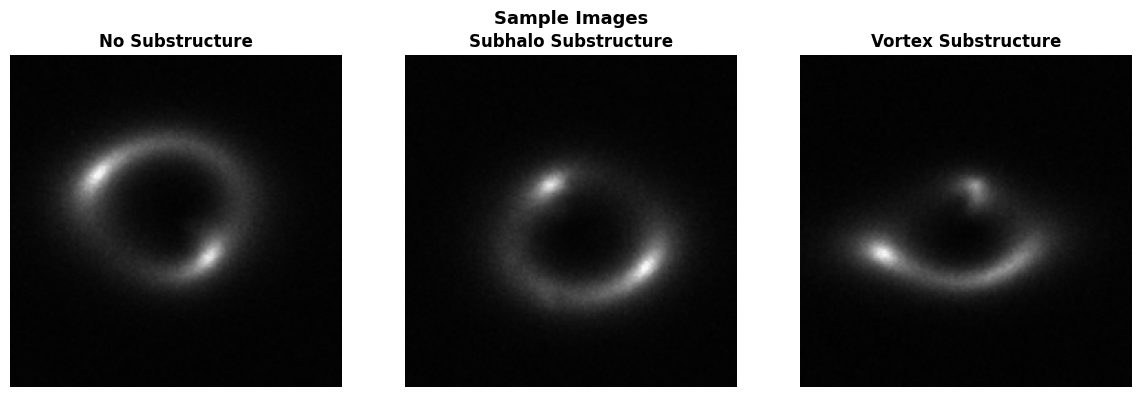

In [7]:
def denorm(t):
    m = torch.tensor([0.485,0.456,0.406]).view(3,1,1)
    s = torch.tensor([0.229,0.224,0.225]).view(3,1,1)
    return (t*s+m).clamp(0,1).permute(1,2,0).numpy()

shown = {}
for img, lbl in train_ds:
    cls = train_ds.idx_to_class[lbl]
    if cls not in shown: shown[cls] = img
    if len(shown) == 3: break

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, cls in zip(axes, CLASS_NAMES):
    ax.imshow(denorm(shown[cls]), cmap='magma')
    ax.set_title(CLASS_LABELS[cls], fontweight='bold'); ax.axis('off')
plt.suptitle('Sample Images', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Model

In [8]:
model = models.efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
model.classifier = nn.Sequential(
    nn.Dropout(0.3, inplace=True),
    nn.Linear(model.classifier[1].in_features, NUM_CLASSES)
)
model = model.to(device)
print(f'Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

2.4%

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /home/harshil/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100.0%


Trainable params: 4,011,391


## 7. Training

In [9]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

def run(model, dl, train=True):
    model.train() if train else model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for x, y in dl:
            x, y = x.to(device), y.to(device)
            if train: optimizer.zero_grad()
            out  = model(x)
            loss = criterion(out, y)
            if train: loss.backward(); optimizer.step()
            loss_sum += loss.item() * x.size(0)
            correct  += out.argmax(1).eq(y).sum().item()
            total    += x.size(0)
    return loss_sum/total, 100*correct/total

history = {'tl':[], 'ta':[], 'vl':[], 'va':[]}
best_acc, best_path = 0.0, 'best_model.pth'

print(f"{'Ep':>4} | {'TrLoss':>8} | {'TrAcc':>7} | {'VaLoss':>8} | {'VaAcc':>7}")
print('-' * 47)

for ep in range(1, NUM_EPOCHS+1):
    tl, ta = run(model, train_dl, train=True)
    vl, va = run(model, val_dl,   train=False)
    scheduler.step()
    history['tl'].append(tl); history['ta'].append(ta)
    history['vl'].append(vl); history['va'].append(va)
    flag = ' ★' if va > best_acc else ''
    print(f"{ep:>4} | {tl:>8.4f} | {ta:>6.2f}% | {vl:>8.4f} | {va:>6.2f}%{flag}")
    if va > best_acc:
        best_acc = va
        torch.save({'epoch': ep, 'state': model.state_dict(), 'val_acc': va}, best_path)

print(f'\nBest val accuracy: {best_acc:.2f}%')

  Ep |   TrLoss |   TrAcc |   VaLoss |   VaAcc
-----------------------------------------------
   1 |   1.0595 |  42.36% |   0.9696 |  53.81% ★
   2 |   0.8796 |  61.53% |   0.8406 |  65.71% ★
   3 |   0.7412 |  72.25% |   0.7301 |  73.49% ★
   4 |   0.6548 |  78.43% |   0.6411 |  79.39% ★
   5 |   0.6043 |  81.79% |   0.5852 |  82.81% ★
   6 |   0.5633 |  84.65% |   0.5809 |  83.11% ★
   7 |   0.5358 |  86.41% |   0.5629 |  84.79% ★
   8 |   0.5150 |  87.53% |   0.5776 |  84.25%
   9 |   0.4941 |  88.93% |   0.5073 |  87.81% ★
  10 |   0.4773 |  89.91% |   0.5527 |  85.97%
  11 |   0.4589 |  90.76% |   0.4670 |  90.68% ★
  12 |   0.4524 |  91.18% |   0.4636 |  90.91% ★
  13 |   0.4424 |  91.83% |   0.4849 |  89.45%
  14 |   0.4273 |  92.74% |   0.4732 |  90.39%
  15 |   0.4222 |  92.87% |   0.4589 |  91.09% ★
  16 |   0.4140 |  93.39% |   0.4520 |  91.71% ★
  17 |   0.4087 |  93.69% |   0.4403 |  92.36% ★
  18 |   0.4031 |  94.04% |   0.4410 |  92.37% ★
  19 |   0.3960 |  94.38% |   0

## 8. Training Curves

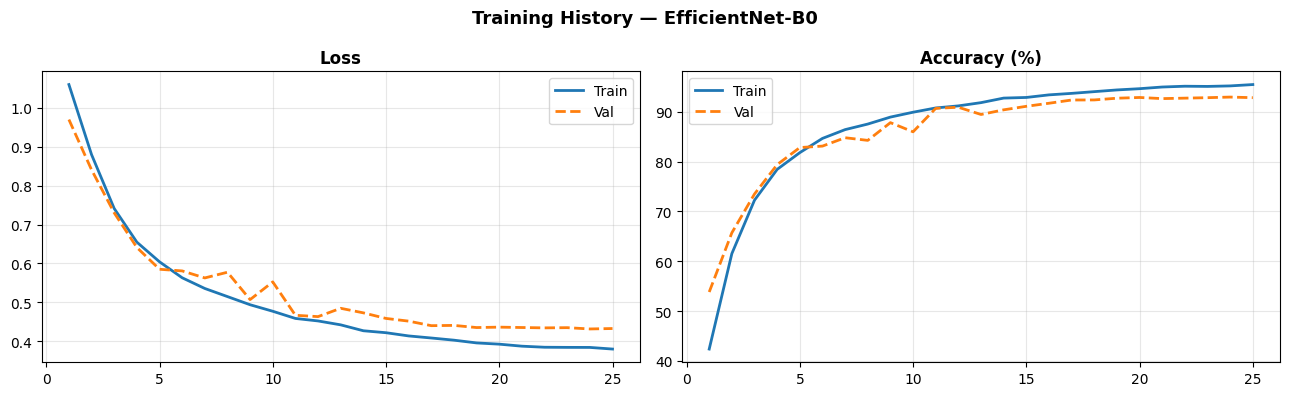

In [10]:
ep = range(1, NUM_EPOCHS+1)
fig, (a1,a2) = plt.subplots(1,2,figsize=(13,4))
a1.plot(ep,history['tl'],label='Train',lw=2); a1.plot(ep,history['vl'],label='Val',lw=2,ls='--')
a1.set_title('Loss',fontweight='bold'); a1.legend(); a1.grid(alpha=0.3)
a2.plot(ep,history['ta'],label='Train',lw=2); a2.plot(ep,history['va'],label='Val',lw=2,ls='--')
a2.set_title('Accuracy (%)',fontweight='bold'); a2.legend(); a2.grid(alpha=0.3)
plt.suptitle('Training History — EfficientNet-B0',fontsize=13,fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png',dpi=150,bbox_inches='tight')
plt.show()

## 9. Load Best Model and Collect Predictions

In [11]:
ckpt = torch.load(best_path, map_location=device)
model.load_state_dict(ckpt['state'])
print(f"Best model — epoch {ckpt['epoch']}, val_acc={ckpt['val_acc']:.2f}%")

model.eval()
all_labels, all_probs, all_preds = [], [], []
with torch.no_grad():
    for x, y in val_dl:
        p = torch.softmax(model(x.to(device)), dim=1)
        all_labels.extend(y.numpy())
        all_probs.extend(p.cpu().numpy())
        all_preds.extend(p.argmax(1).cpu().numpy())

all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)
all_preds  = np.array(all_preds)
print(f'Val samples: {len(all_labels):,}')

Best model — epoch 24, val_acc=92.95%
Val samples: 7,500


## 10. ROC Curves and AUC Scores

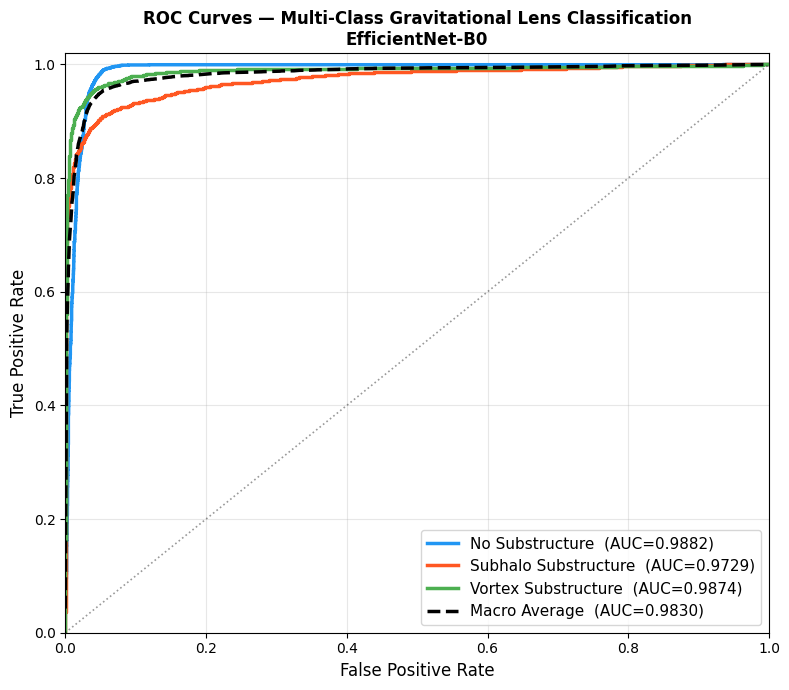


=== AUC SCORES ===
  No Substructure             : 0.9882
  Subhalo Substructure        : 0.9729
  Vortex Substructure         : 0.9874
  Macro Average               : 0.9830


In [12]:
names  = ['No Substructure', 'Subhalo Substructure', 'Vortex Substructure']
colors = ['#2196F3', '#FF5722', '#4CAF50']
lb     = label_binarize(all_labels, classes=[0,1,2])

fpr, tpr, auc_score = {}, {}, {}
for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(lb[:,i], all_probs[:,i])
    auc_score[i]      = auc(fpr[i], tpr[i])

all_fpr  = np.unique(np.concatenate([fpr[i] for i in range(3)]))
mean_tpr = sum(np.interp(all_fpr, fpr[i], tpr[i]) for i in range(3)) / 3
macro    = auc(all_fpr, mean_tpr)

fig, ax = plt.subplots(figsize=(8,7))
for i in range(3):
    ax.plot(fpr[i], tpr[i], color=colors[i], lw=2.5, label=f'{names[i]}  (AUC={auc_score[i]:.4f})')
ax.plot(all_fpr, mean_tpr, 'k--', lw=2.5, label=f'Macro Average  (AUC={macro:.4f})')
ax.plot([0,1],[0,1],'k:',lw=1.2,alpha=0.4)
ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
ax.set_xlabel('False Positive Rate',fontsize=12)
ax.set_ylabel('True Positive Rate',fontsize=12)
ax.set_title('ROC Curves — Multi-Class Gravitational Lens Classification\nEfficientNet-B0',
             fontsize=12,fontweight='bold')
ax.legend(loc='lower right',fontsize=11); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png',dpi=150,bbox_inches='tight')
plt.show()

print('\n=== AUC SCORES ===')
for i,n in enumerate(names):
    print(f'  {n:<28}: {auc_score[i]:.4f}')
print(f'  {"Macro Average":<28}: {macro:.4f}')

## 11. Confusion Matrix

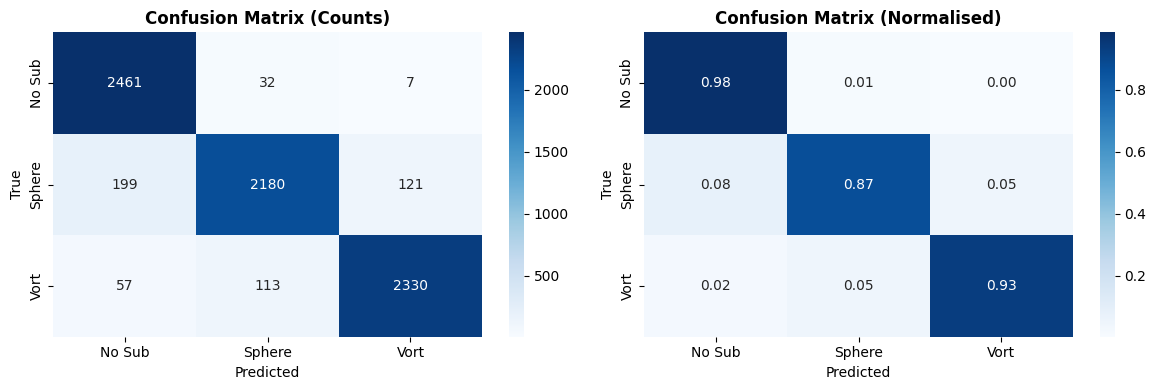

In [13]:
cm   = confusion_matrix(all_labels, all_preds)
cmn  = cm.astype('float') / cm.sum(axis=1, keepdims=True)
tk   = ['No Sub','Sphere','Vort']
fig,(a1,a2) = plt.subplots(1,2,figsize=(12,4))
for ax,d,f,t in [(a1,cm,'d','Counts'),(a2,cmn,'.2f','Normalised')]:
    sns.heatmap(d,annot=True,fmt=f,cmap='Blues',ax=ax,xticklabels=tk,yticklabels=tk)
    ax.set_title(f'Confusion Matrix ({t})',fontweight='bold')
    ax.set_ylabel('True'); ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png',dpi=150,bbox_inches='tight')
plt.show()

## 12. Classification Report

In [ ]:
print(classification_report(all_labels, all_preds, target_names=names))

## 13. Final Summary

In [14]:
print('='*56)
print('  TEST I — MULTI-CLASS GRAVITATIONAL LENS CLASSIFICATION')
print('='*56)
print(f'  Model         : EfficientNet-B0 (ImageNet pretrained)')
print(f'  Epochs        : {NUM_EPOCHS}')
print(f'  Best val acc  : {best_acc:.2f}%')
print(f'  Final val acc : {100*(all_preds==all_labels).mean():.2f}%')
print()
print('  AUC (one-vs-rest):')
for i,n in enumerate(names):
    print(f'    {n:<26}: {auc_score[i]:.4f}')
print(f'    {"Macro Average":<26}: {macro:.4f}')
print('='*56)

  TEST I — MULTI-CLASS GRAVITATIONAL LENS CLASSIFICATION
  Model         : EfficientNet-B0 (ImageNet pretrained)
  Epochs        : 25
  Best val acc  : 92.95%
  Final val acc : 92.95%

  AUC (one-vs-rest):
    No Substructure           : 0.9882
    Subhalo Substructure      : 0.9729
    Vortex Substructure       : 0.9874
    Macro Average             : 0.9830


## 14. Discussion

### Model: EfficientNet-B0
Chosen over ResNet18 or custom CNNs because compound scaling (depth + width + resolution together) captures the subtle morphological differences between substructure types more effectively. ~5.3M parameters, faster convergence than ResNet18 on fine-grained tasks.

### Data Handling
Each `.npy` file is a pre-normalised lensing image. I apply per-image [0,1] min-max normalisation, replicate single-channel arrays to 3 channels for ImageNet backbone compatibility, then apply standard ImageNet mean/std normalisation.

### Training
- **Label smoothing (0.1):** The three classes look visually similar — smoothing prevents overconfidence
- **AdamW:** Weight decay provides implicit regularisation
- **Cosine annealing LR:** Smooth decay avoids oscillation near convergence
- **Augmentation:** Random H/V flips are physically valid — no preferred orientation in gravitational lensing

### Dataset
- Train: 30,000 samples (10,000 × 3 classes)
- Val: ~7,500 samples (~2,500 × 3 classes)
- Pre-split by dataset providers — used as-is per test instructions

---
*Harshil Makhija — ML4SCI GSoC 2026 — DEEPLENSE1*